In [1]:
import sys
print(sys.executable)

/Users/talirabban/Desktop/Thesis/.venv/bin/python


# Snapshot Dataset Sanity Checks

This notebook checks the output of `src/build_snapshots.py`, which converts raw Polymarket YES-token price histories into a fixed-horizon snapshot dataset.

Each row represents one market at one pre-resolution snapshot time, such as T-1h, T-6h, T-24h, or T-72h before the market's `endDate`.

The goal of this notebook is to verify that the snapshot dataset is clean enough to use for:

1. Part I: static calibration and market efficiency analysis
2. Part II: dynamic predictability and alpha modeling

## 1. Load Snapshot Dataset

This section imports the required libraries and loads the processed snapshot dataset from `data/processed/snapshots.parquet`.

The dataset should contain fixed pre-close snapshots, market metadata, engineered price features, and final binary outcomes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [42]:
SNAPSHOT_PATH = Path("../data/processed/snapshots.parquet")
df = pd.read_parquet(SNAPSHOT_PATH)
print(f"Loaded {len(df):,} snapshot rows")
print(f"Columns: {len(df.columns)}")
df.head()

Loaded 38,972 snapshot rows
Columns: 15


,condition_id,snapshot_offset_h,snapshot_time,close_time,hours_to_expiry,price_level,momentum_1h,momentum_6h,momentum_1d,momentum_3d,price_volatility,log_volume,category,yes_resolution,calibration_error
0,0x00001032adc2a18f836a38d7da2ffc1d81cbcf44f9a8...,1,1.778211e+09,1.778215e+09,1.0,0.5050,0.0,0.0000,NaN,NaN,0.000000,11.849083,Crypto,1.0,0.4950
1,0x00001032adc2a18f836a38d7da2ffc1d81cbcf44f9a8...,6,1.778193e+09,1.778215e+09,6.0,0.5050,0.0,0.0000,NaN,NaN,0.000000,11.849083,Crypto,1.0,0.4950
2,0x00015ed356b270f608454e34dee8b6b9c70a05e33747...,1,1.777729e+09,1.777732e+09,1.0,0.5050,0.0,0.0000,NaN,NaN,0.000000,10.579429,Crypto,1.0,0.4950
3,0x00015ed356b270f608454e34dee8b6b9c70a05e33747...,6,1.777711e+09,1.777732e+09,6.0,0.5050,0.0,0.0000,NaN,NaN,0.000000,10.579429,Crypto,1.0,0.4950
4,0x00019b4779ee277992416526625c69b9045e6e4e888e...,1,1.777500e+09,1.777504e+09,1.0,0.9995,0.0,0.1445,NaN,NaN,0.021177,12.336424,Sports,1.0,0.0005


## 2. Basic Dataset Structure

This section checks the shape, columns, and data types of the snapshot dataset.

The most important fields are:

- `condition_id`: unique market identifier
- `snapshot_offset_h`: number of hours before market close
- `snapshot_time`: timestamp of the price snapshot
- `close_time`: market end/resolution timestamp
- `price_level`: YES-token price at the snapshot
- `yes_resolution`: final binary outcome, where 1 means YES resolved correctly

In [5]:
print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

print("\nData types:")
df.dtypes

Shape: (38972, 15)

Columns:
condition_id
snapshot_offset_h
snapshot_time
close_time
hours_to_expiry
price_level
momentum_1h
momentum_6h
momentum_1d
momentum_3d
price_volatility
log_volume
category
yes_resolution
calibration_error

Data types:


condition_id          object
snapshot_offset_h      int64
snapshot_time        float64
close_time           float64
hours_to_expiry      float64
price_level          float64
momentum_1h          float64
momentum_6h          float64
momentum_1d          float64
momentum_3d          float64
price_volatility     float64
log_volume           float64
category              object
yes_resolution       float64
calibration_error    float64
dtype: object

## 3. High-Level Dataset Summary

This section summarizes the number of snapshot rows, unique markets, categories, price range, and overall YES resolution rate.

This gives a quick check that the dataset size and basic values are reasonable.

In [51]:
summary = {
    "snapshot_rows": len(df),
    "unique_markets": df["condition_id"].nunique() if "condition_id" in df.columns else np.nan,
    "categories": df["category"].nunique() if "category" in df.columns else np.nan,
    "min_price": df["price_level"].min(),
    "max_price": df["price_level"].max(),
    "mean_price": df["price_level"].mean(),
    "yes_resolved_rate": df["yes_resolution"].mean() if "yes_resolution" in df.columns else np.nan,
}

pd.DataFrame([summary]).T.rename(columns={0: "value"})

,value
snapshot_rows,38972.000000
unique_markets,13656.000000
categories,5.000000
min_price,0.000500
max_price,0.999500
mean_price,0.395793
yes_resolved_rate,0.400801


## 4. Snapshot Horizon Coverage

This section counts how many observations are available at each fixed pre-close horizon.

The expected horizons are:

- T-1h
- T-6h
- T-24h
- T-72h

Coverage should be highest at short horizons and lower at longer horizons because not every market has enough historical price data.

In [7]:
offset_counts = df["snapshot_offset_h"].value_counts().sort_index()
offset_counts

snapshot_offset_h
1     13445
6     13490
24     7475
72     4562
Name: count, dtype: int64

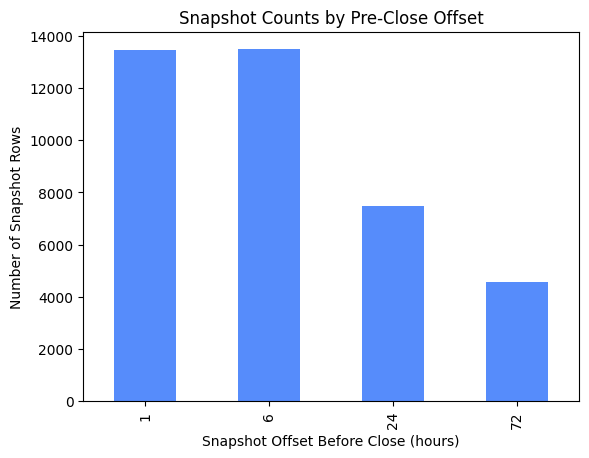

In [8]:
offset_counts.plot(kind="bar")
plt.title("Snapshot Counts by Pre-Close Offset")
plt.xlabel("Snapshot Offset Before Close (hours)")
plt.ylabel("Number of Snapshot Rows")
plt.show()

## 5. Category Distribution

This section examines the composition of the dataset by market category.

Both snapshot-level and market-level category counts are useful:

- Snapshot-level counts show how many rows each category contributes.
- Market-level counts show how many distinct markets are in each category.

This distinction matters because one market can contribute multiple snapshot rows.

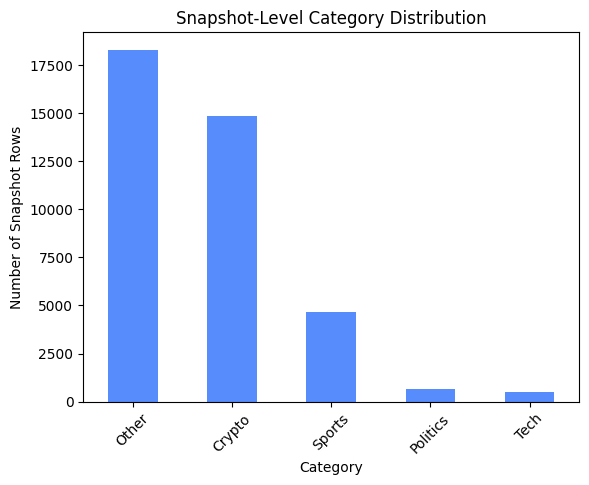

In [9]:
category_counts = df["category"].value_counts()
category_counts.plot(kind="bar")
plt.title("Snapshot-Level Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Snapshot Rows")
plt.xticks(rotation=45)
plt.show()

In [10]:
market_category = (
    df.drop_duplicates("condition_id")
      .groupby("category")["condition_id"]
      .count()
      .sort_values(ascending=False)
)

market_category

category
Crypto      6587
Other       5263
Sports      1488
Politics     182
Tech         136
Name: condition_id, dtype: int64

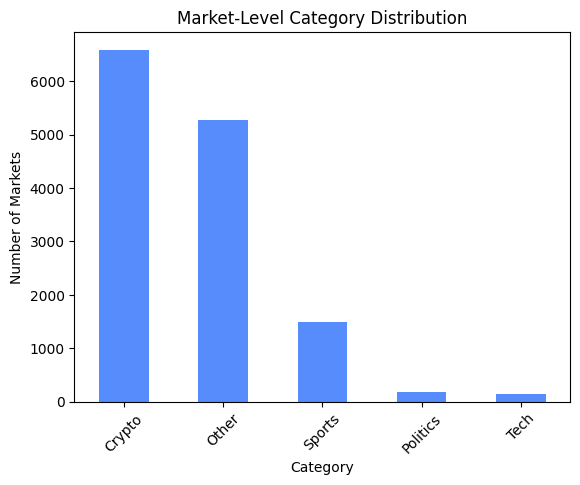

In [11]:
market_category.plot(kind="bar")
plt.title("Market-Level Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Markets")
plt.xticks(rotation=45)
plt.show()

## 6. Feature Missingness

This section checks the null rate for engineered price features.

Short-horizon features like `momentum_1h` and `momentum_6h` should have low missingness. Longer-horizon features like `momentum_1d` and `momentum_3d` are expected to have higher missingness because many markets do not have enough prior price history.

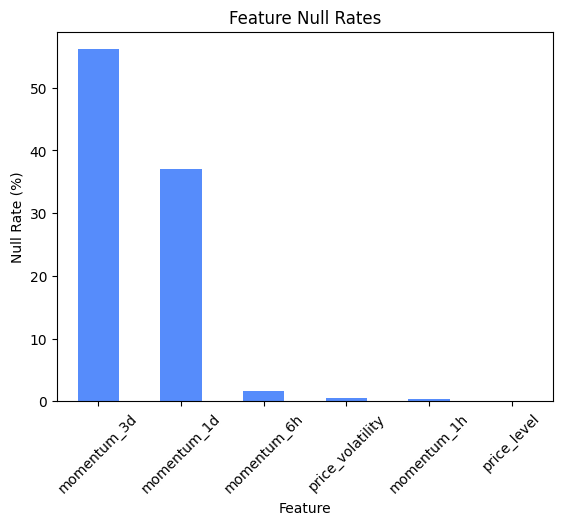

In [12]:
feature_cols = [
    "price_level",
    "momentum_1h",
    "momentum_6h",
    "momentum_1d",
    "momentum_3d",
    "price_volatility",
]

existing_feature_cols = [c for c in feature_cols if c in df.columns]

null_rates = df[existing_feature_cols].isna().mean().sort_values(ascending=False) * 100
null_rates.round(2)

null_rates.plot(kind="bar")
plt.title("Feature Null Rates")
plt.xlabel("Feature")
plt.ylabel("Null Rate (%)")
plt.xticks(rotation=45)
plt.show()
df["price_level"].describe()
plt.hist(df["price_level"].dropna(), bins=50)
plt.title("Distribution of Snapshot Prices")
plt.xlabel("YES Price / Implied Probability")
plt.ylabel("Count")
plt.show()

## 7. Price Distribution

This section checks the distribution of snapshot YES prices.

Because prediction market prices represent implied probabilities, valid values should lie between 0 and 1. It is also useful to check for clustering around focal prices such as 0.50, 0.99, or 0.01.

In [14]:
df["price_rounded_3"] = df["price_level"].round(3)

df["price_rounded_3"].value_counts().head(25)

df["price_rounded_2"] = df["price_level"].round(2)

df["price_rounded_2"].value_counts().head(25)


price_rounded_2
0.50    13040
0.00     4367
1.00     1278
0.01     1243
0.02      678
0.48      667
0.52      567
0.28      552
0.26      545
0.46      518
0.24      509
0.44      497
0.38      481
0.36      473
0.30      469
0.42      465
0.40      455
0.32      441
0.56      418
0.34      414
0.04      392
0.03      383
0.22      380
0.20      372
0.16      337
Name: count, dtype: int64

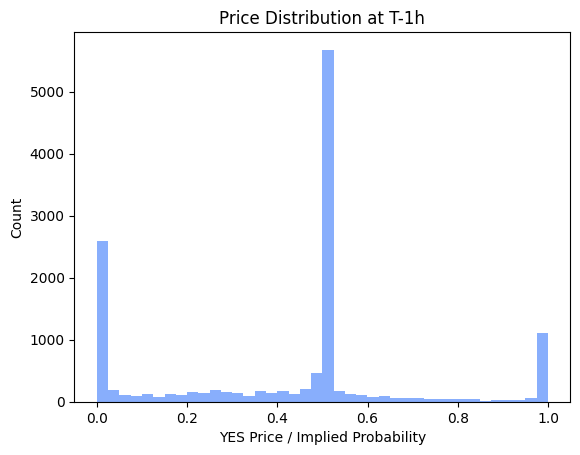

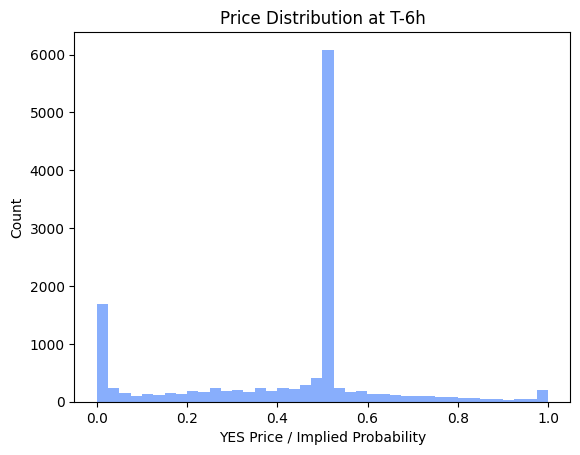

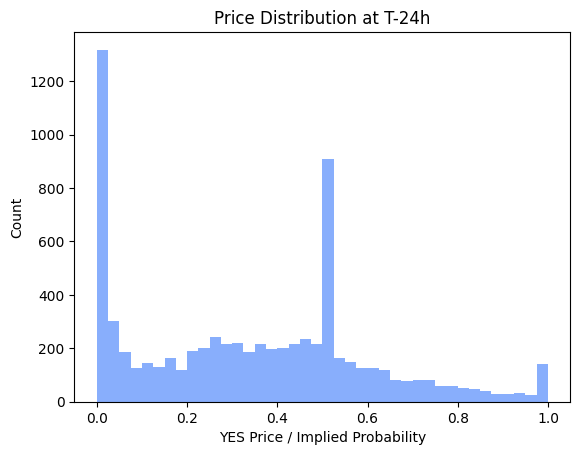

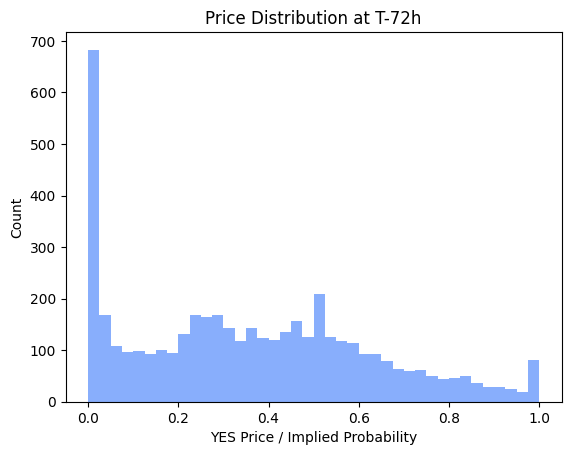

In [15]:
df.groupby("snapshot_offset_h")["price_level"].describe().round(3)
for offset in sorted(df["snapshot_offset_h"].dropna().unique()):
    subset = df[df["snapshot_offset_h"] == offset]
    plt.hist(subset["price_level"].dropna(), bins=40, alpha=0.7)
    plt.title(f"Price Distribution at T-{int(offset)}h")
    plt.xlabel("YES Price / Implied Probability")
    plt.ylabel("Count")
    plt.show()

## 8. Calibration Analysis

This section begins the Part I efficiency analysis.

Prices are grouped into probability bins, and the average market-implied probability is compared to the empirical YES resolution rate.

Calibration error is defined as:

$\text{calibration error} = \text{empirical YES rate} - \text{average market price}$

Positive calibration error means the contract resolved YES more often than the market price implied. Negative calibration error means it resolved YES less often than implied.

In [20]:
df["price_bin"] = pd.cut(
    df["price_level"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

calibration = (
    df.groupby("price_bin", observed=True)
      .agg(
          n=("yes_resolution", "size"),
          avg_price=("price_level", "mean"),
          empirical_yes_rate=("yes_resolution", "mean"),
      )
      .reset_index()
)

calibration["calibration_error"] = calibration["empirical_yes_rate"] - calibration["avg_price"]

calibration.round(3)

,price_bin,n,avg_price,empirical_yes_rate,calibration_error
0,"(-0.001, 0.1]",8156,0.017,0.024,0.007
1,"(0.1, 0.2]",1880,0.152,0.215,0.063
2,"(0.2, 0.3]",2909,0.254,0.326,0.073
3,"(0.3, 0.4]",2702,0.352,0.373,0.020
4,"(0.4, 0.5]",5288,0.472,0.469,-0.004
5,"(0.5, 0.6]",12948,0.513,0.509,-0.004
6,"(0.6, 0.7]",1492,0.646,0.595,-0.051
7,"(0.7, 0.8]",1012,0.748,0.685,-0.063
8,"(0.8, 0.9]",672,0.845,0.795,-0.050
9,"(0.9, 1.0]",1913,0.986,0.985,-0.001


## 9. Calibration Curve

This plot compares market-implied probabilities to empirical outcome frequencies.

The dashed diagonal line represents perfect calibration. Points above the line suggest underpricing of YES contracts, while points below the line suggest overpricing.

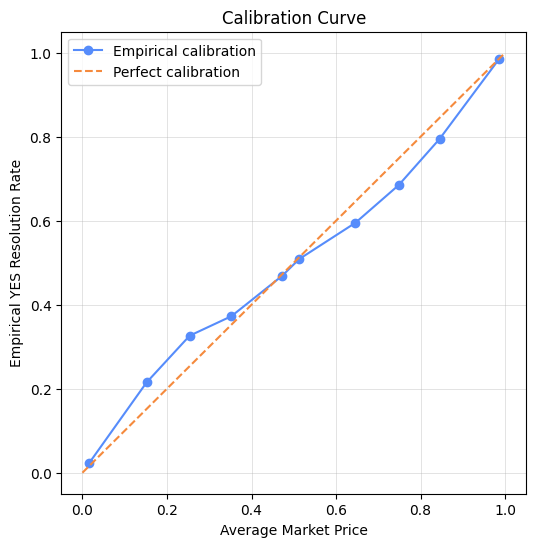

In [21]:
plt.figure(figsize=(6, 6))

plt.plot(
    calibration["avg_price"],
    calibration["empirical_yes_rate"],
    marker="o",
    label="Empirical calibration"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.title("Calibration Curve")
plt.xlabel("Average Market Price")
plt.ylabel("Empirical YES Resolution Rate")
plt.legend()
plt.grid(True)
plt.show()

## 10. Calibration by Snapshot Horizon

This section repeats the calibration analysis separately for each pre-close horizon.

This helps check whether market prices become better calibrated closer to resolution.

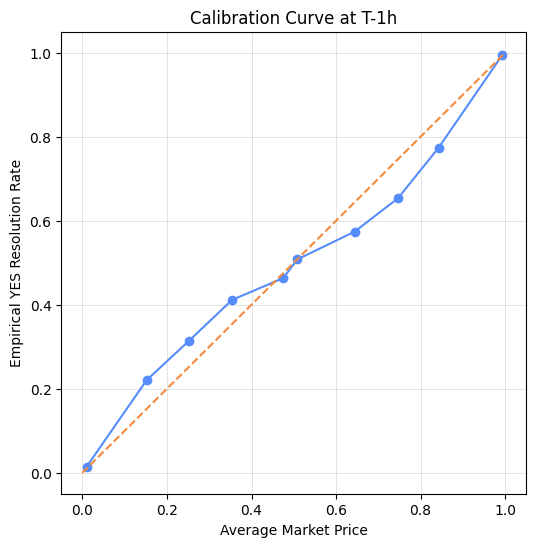

,price_bin,n,avg_price,empirical_yes_rate
0,"(-0.001, 0.1]",2982,0.010,0.014
1,"(0.1, 0.2]",417,0.152,0.221
2,"(0.2, 0.3]",639,0.253,0.315
3,"(0.3, 0.4]",559,0.354,0.411
4,"(0.4, 0.5]",1312,0.475,0.463
5,"(0.5, 0.6]",5733,0.509,0.508
6,"(0.6, 0.7]",284,0.644,0.574
7,"(0.7, 0.8]",173,0.746,0.653
8,"(0.8, 0.9]",137,0.843,0.774
9,"(0.9, 1.0]",1209,0.994,0.995


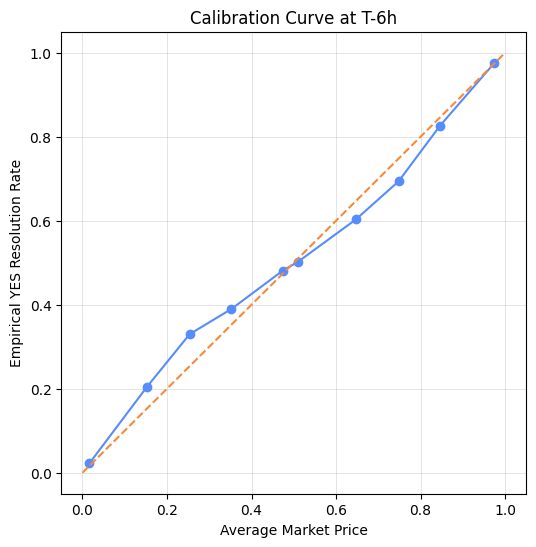

,price_bin,n,avg_price,empirical_yes_rate
0,"(-0.001, 0.1]",2185,0.017,0.022
1,"(0.1, 0.2]",519,0.153,0.204
2,"(0.2, 0.3]",788,0.254,0.330
3,"(0.3, 0.4]",795,0.353,0.390
4,"(0.4, 0.5]",1778,0.474,0.481
5,"(0.5, 0.6]",6056,0.511,0.503
6,"(0.6, 0.7]",476,0.647,0.603
7,"(0.7, 0.8]",343,0.748,0.694
8,"(0.8, 0.9]",224,0.846,0.826
9,"(0.9, 1.0]",326,0.974,0.975


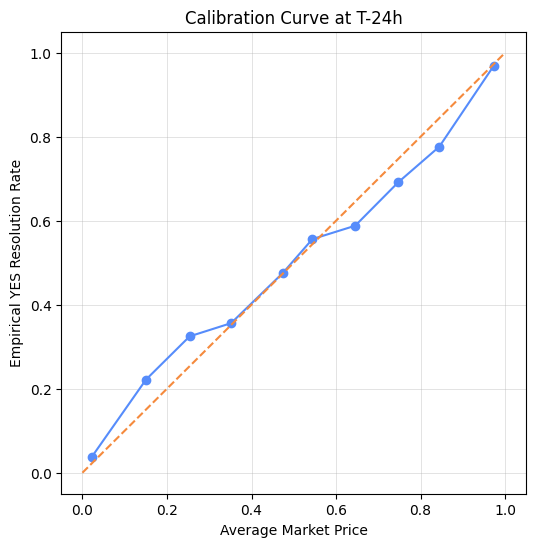

,price_bin,n,avg_price,empirical_yes_rate
0,"(-0.001, 0.1]",1932,0.022,0.038
1,"(0.1, 0.2]",559,0.150,0.222
2,"(0.2, 0.3]",850,0.254,0.325
3,"(0.3, 0.4]",820,0.352,0.356
4,"(0.4, 0.5]",1575,0.474,0.476
5,"(0.5, 0.6]",667,0.544,0.556
6,"(0.6, 0.7]",403,0.645,0.588
7,"(0.7, 0.8]",279,0.747,0.692
8,"(0.8, 0.9]",161,0.844,0.776
9,"(0.9, 1.0]",229,0.973,0.969


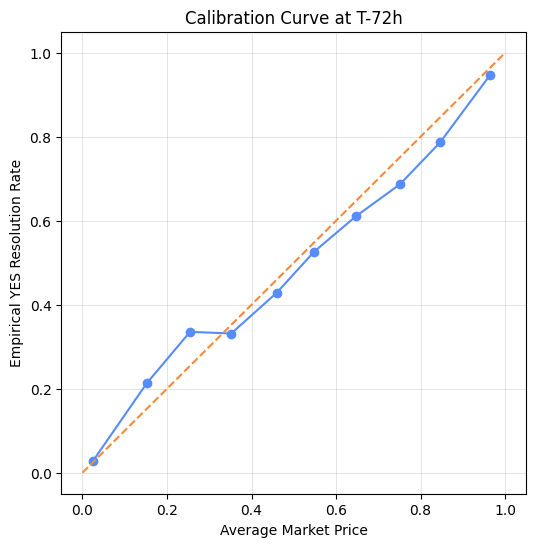

,price_bin,n,avg_price,empirical_yes_rate
0,"(-0.001, 0.1]",1057,0.025,0.028
1,"(0.1, 0.2]",385,0.152,0.213
2,"(0.2, 0.3]",632,0.255,0.335
3,"(0.3, 0.4]",528,0.352,0.331
4,"(0.4, 0.5]",623,0.460,0.429
5,"(0.5, 0.6]",492,0.548,0.526
6,"(0.6, 0.7]",329,0.647,0.611
7,"(0.7, 0.8]",217,0.751,0.687
8,"(0.8, 0.9]",150,0.846,0.787
9,"(0.9, 1.0]",149,0.964,0.946


In [23]:
for offset in sorted(df["snapshot_offset_h"].dropna().unique()):
    subset = df[df["snapshot_offset_h"] == offset].copy()

    subset["price_bin"] = pd.cut(
        subset["price_level"],
        bins=np.linspace(0, 1, 11),
        include_lowest=True
    )

    cal = (
        subset.groupby("price_bin", observed=True)
              .agg(
                  n=("yes_resolution", "size"),
                  avg_price=("price_level", "mean"),
                  empirical_yes_rate=("yes_resolution", "mean"),
              )
              .reset_index()
    )

    plt.figure(figsize=(6, 6))
    plt.plot(cal["avg_price"], cal["empirical_yes_rate"], marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Calibration Curve at T-{int(offset)}h")
    plt.xlabel("Average Market Price")
    plt.ylabel("Empirical YES Resolution Rate")
    plt.grid(True)
    plt.show()

    display(cal.round(3))

## 11. Brier Score

The Brier score measures probabilistic forecast accuracy for binary outcomes:


$$\text{Brier score} = (p_i - y_i)^2$$

where $p_i$ is the market-implied probability and $y_i$ is the final binary outcome.

Lower Brier scores indicate better forecast accuracy. A naive 50/50 forecast has a Brier score around 0.25.

In [24]:
df["brier"] = (df["price_level"] - df["yes_resolution"]) ** 2

overall_brier = df["brier"].mean()

print(f"Overall Brier score: {overall_brier:.4f}")

brier_by_offset = (
    df.groupby("snapshot_offset_h")
      .agg(
          n=("brier", "size"),
          brier_score=("brier", "mean"),
          avg_price=("price_level", "mean"),
          yes_rate=("yes_resolution", "mean"),
      )
      .reset_index()
)

brier_by_offset.round(4)

Overall Brier score: 0.1810


,snapshot_offset_h,n,brier_score,avg_price,yes_rate
0,1,13445,0.1701,0.4181,0.4219
1,6,13490,0.1989,0.4152,0.4190
2,24,7475,0.1731,0.3436,0.3561
3,72,4562,0.1728,0.3583,0.3582


## 12. Forecast Accuracy by Category

This section compares Brier scores across market categories.

Category-level results should be interpreted carefully because some categories have many more observations than others.

In [25]:
brier_by_category = (
    df.groupby("category")
      .agg(
          n=("brier", "size"),
          brier_score=("brier", "mean"),
          avg_price=("price_level", "mean"),
          yes_rate=("yes_resolution", "mean"),
      )
      .sort_values("n", ascending=False)
      .reset_index()
)

brier_by_category.round(4)

,category,n,brier_score,avg_price,yes_rate
0,Other,18293,0.1668,0.3150,0.3283
1,Crypto,14838,0.2148,0.4663,0.4666
2,Sports,4663,0.1551,0.5190,0.5035
3,Politics,678,0.0641,0.2041,0.1991
4,Tech,500,0.0963,0.3728,0.4160


## 13. Favorite-Longshot Bias Check

This section checks whether low-probability and high-probability contracts are systematically miscalibrated.

In prediction markets, a favorite-longshot pattern would appear if low-priced contracts and high-priced contracts have different calibration errors.

In [26]:
favorite_longshot = calibration.copy()

favorite_longshot["bias_type"] = np.where(
    favorite_longshot["calibration_error"] > 0,
    "underpriced",
    "overpriced"
)

favorite_longshot.round(3)

,price_bin,n,avg_price,empirical_yes_rate,calibration_error,bias_type
0,"(-0.001, 0.1]",8156,0.017,0.024,0.007,underpriced
1,"(0.1, 0.2]",1880,0.152,0.215,0.063,underpriced
2,"(0.2, 0.3]",2909,0.254,0.326,0.073,underpriced
3,"(0.3, 0.4]",2702,0.352,0.373,0.020,underpriced
4,"(0.4, 0.5]",5288,0.472,0.469,-0.004,overpriced
5,"(0.5, 0.6]",12948,0.513,0.509,-0.004,overpriced
6,"(0.6, 0.7]",1492,0.646,0.595,-0.051,overpriced
7,"(0.7, 0.8]",1012,0.748,0.685,-0.063,overpriced
8,"(0.8, 0.9]",672,0.845,0.795,-0.050,overpriced
9,"(0.9, 1.0]",1913,0.986,0.985,-0.001,overpriced


## 14. Dynamic Feature Sanity Checks

This section checks the engineered dynamic features that will later be used in Part II.

These include short-term and longer-term momentum features, price volatility, and price level.

The goal here is not to build a model yet, but to make sure the feature distributions look plausible.

In [27]:
numeric_cols = [
    "price_level",
    "momentum_1h",
    "momentum_6h",
    "momentum_1d",
    "momentum_3d",
    "price_volatility",
    "brier",
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

df[numeric_cols].describe().round(4)

,price_level,momentum_1h,momentum_6h,momentum_1d,momentum_3d,price_volatility,brier
count,38972.0000,38838.0000,38316.0000,24566.0000,17103.0000,38751.0000,38972.0000
mean,0.3958,0.0000,0.0005,0.0025,-0.0056,0.0148,0.1810
std,0.2584,0.0495,0.1160,0.1454,0.1426,0.0319,0.1646
min,0.0005,-0.9520,-0.9600,-0.9550,-0.9235,0.0000,0.0000
25%,0.1850,0.0000,-0.0010,-0.0150,-0.0215,0.0000,0.0090
50%,0.5000,0.0000,0.0000,0.0000,-0.0005,0.0025,0.2304
75%,0.5050,0.0000,0.0000,0.0100,0.0150,0.0104,0.2550
max,0.9995,0.9460,0.9895,0.9935,0.9760,0.3516,0.9990


In [28]:
momentum_cols = [
    "momentum_1h",
    "momentum_6h",
    "momentum_1d",
    "momentum_3d",
]

momentum_cols = [c for c in momentum_cols if c in df.columns]

for col in momentum_cols:
    print(f"\n{col}")
    print(df[col].describe().round(4))


momentum_1h
count    38838.0000
mean         0.0000
std          0.0495
min         -0.9520
25%          0.0000
50%          0.0000
75%          0.0000
max          0.9460
Name: momentum_1h, dtype: float64

momentum_6h
count    38316.0000
mean         0.0005
std          0.1160
min         -0.9600
25%         -0.0010
50%          0.0000
75%          0.0000
max          0.9895
Name: momentum_6h, dtype: float64

momentum_1d
count    24566.0000
mean         0.0025
std          0.1454
min         -0.9550
25%         -0.0150
50%          0.0000
75%          0.0100
max          0.9935
Name: momentum_1d, dtype: float64

momentum_3d
count    17103.0000
mean        -0.0056
std          0.1426
min         -0.9235
25%         -0.0215
50%         -0.0005
75%          0.0150
max          0.9760
Name: momentum_3d, dtype: float64


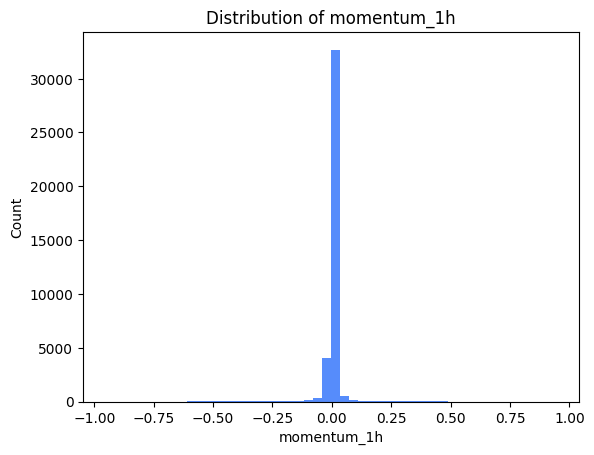

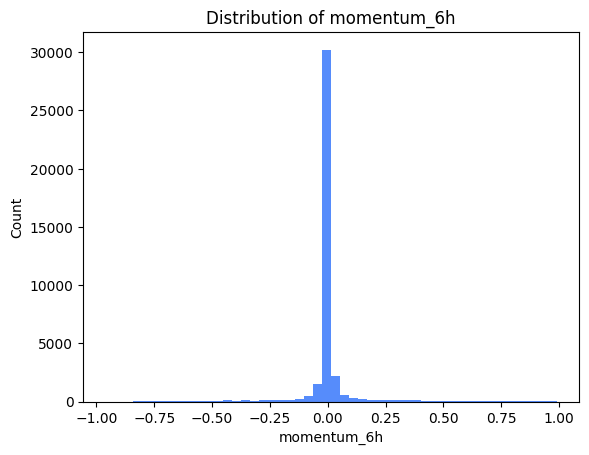

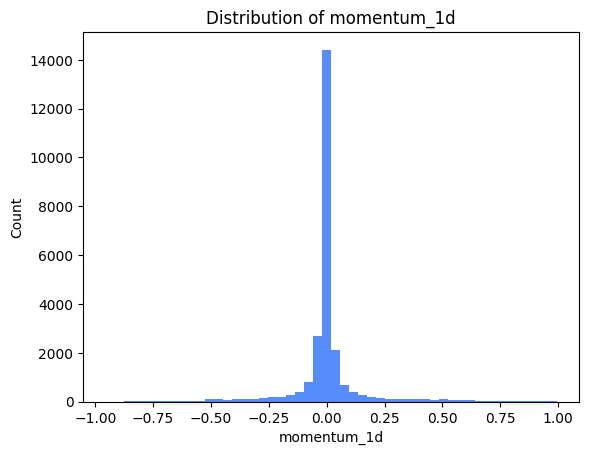

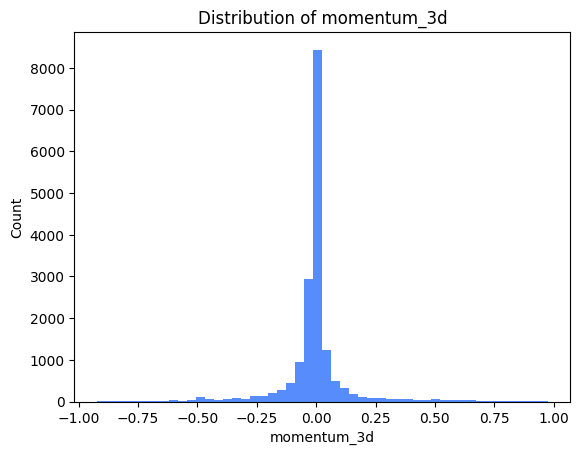

In [29]:
for col in momentum_cols:
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 15. Data Integrity Checks

This section checks for impossible or problematic values.

The main checks are:

- Prices should be between 0 and 1.
- Outcomes should be binary.
- Each market should have at most one row per snapshot horizon.

In [31]:
checks = {
    "price_below_0": (df["price_level"] < 0).sum(),
    "price_above_1": (df["price_level"] > 1).sum(),
    "resolved_yes_not_binary": (~df["yes_resolution"].isin([0, 1])).sum(),
}

pd.Series(checks)

price_below_0              0
price_above_1              0
resolved_yes_not_binary    0
dtype: int64

In [32]:
possible_id_cols = ["condition_id", "snapshot_offset_h"]

if all(c in df.columns for c in possible_id_cols):
    duplicate_count = df.duplicated(possible_id_cols).sum()
    print(f"Duplicate condition_id + snapshot_offset_h rows: {duplicate_count:,}")
else:
    print("Could not run duplicate check because expected ID columns are missing.")

Duplicate condition_id + snapshot_offset_h rows: 0


## 16. Timestamp Conversion

The raw `close_time` and `snapshot_time` columns are stored as Unix timestamps in seconds.

This section converts them into readable datetime columns for plotting and chronological splitting.

This is important because Part II modeling must use chronological train/test splits rather than random splits.

Close time range:
2026-04-19 00:00:00
2026-05-11 04:30:00

Snapshot time range:
2026-04-16 00:00:00
2026-05-11 03:30:00


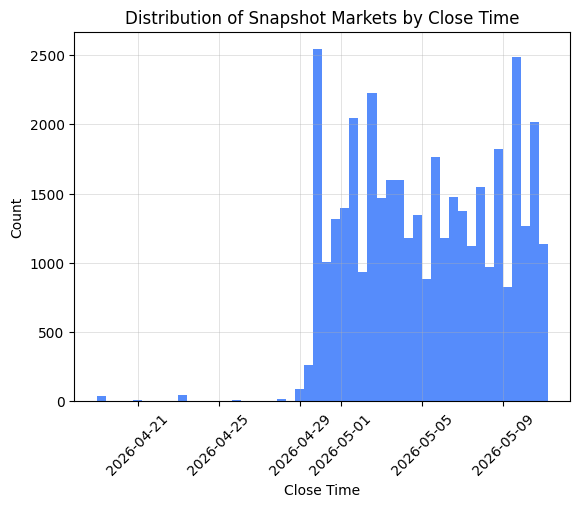

In [48]:
df["close_time_dt"] = pd.to_datetime(df["close_time"], unit="s", errors="coerce")
df["snapshot_time_dt"] = pd.to_datetime(df["snapshot_time"], unit="s", errors="coerce")

print("Close time range:")
print(df["close_time_dt"].min())
print(df["close_time_dt"].max())

print("\nSnapshot time range:")
print(df["snapshot_time_dt"].min())
print(df["snapshot_time_dt"].max())

df["close_time_dt"].hist(bins=50)
plt.title("Distribution of Snapshot Markets by Close Time")
plt.xlabel("Close Time")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 17. Chronological Train/Test Split Preview

This section previews a chronological split by market close time.

This is only a preview for future modeling. For Part II, the final model evaluation should avoid random train/test splitting because that could leak future information into the training set.

In [49]:
split_date_col = "close_time_dt"

market_dates = (
    df.drop_duplicates("condition_id")
      [["condition_id", split_date_col]]
      .dropna()
      .sort_values(split_date_col)
)

split_idx = int(0.7 * len(market_dates))
split_date = market_dates.iloc[split_idx][split_date_col]

print("Chronological split date:", split_date)

train = df[df[split_date_col] <= split_date]
test = df[df[split_date_col] > split_date]

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Train markets: {train['condition_id'].nunique():,}")
print(f"Test markets: {test['condition_id'].nunique():,}")

Chronological split date: 2026-05-07 17:10:00
Train rows: 27,257
Test rows: 11,715
Train markets: 9,561
Test markets: 4,095


## 18. Save Sanity Check Outputs

This section saves key summary tables to `data/processed/sanity_checks`.

These outputs can be reused later for thesis tables, figures, or writeup notes.

In [52]:
OUT_DIR = Path("../data/processed/sanity_checks")
OUT_DIR.mkdir(parents=True, exist_ok=True)

offset_counts.to_csv(OUT_DIR / "snapshot_offset_counts.csv")
category_counts.to_csv(OUT_DIR / "snapshot_category_counts.csv")
market_category.to_csv(OUT_DIR / "market_category_counts.csv")
null_rates.to_csv(OUT_DIR / "feature_null_rates.csv")
calibration.to_csv(OUT_DIR / "calibration_bins.csv", index=False)
brier_by_offset.to_csv(OUT_DIR / "brier_by_offset.csv", index=False)
brier_by_category.to_csv(OUT_DIR / "brier_by_category.csv", index=False)

print(f"Saved sanity check tables to {OUT_DIR}")

Saved sanity check tables to ../data/processed/sanity_checks


## Summary

The snapshot dataset passes the main sanity checks:

- Prices are valid probabilities between 0 and 1.
- Outcomes are clean binary labels.
- There are no duplicate market/horizon rows.
- Short-horizon snapshot coverage is strong.
- Longer-horizon features have expected missingness.
- Calibration and Brier score outputs are usable for Part I analysis.

The dataset is therefore ready for static calibration analysis and later chronological modeling.

# Phase 3

In [55]:
PRED_PATH = Path("../data/processed/test_predictions.parquet")
df = pd.read_parquet(PRED_PATH)
print("pred_EN:", df["pred_EN"].abs().max(), df["pred_EN"].describe())
print("pred_RF:", df["pred_RF"].abs().max(), df["pred_RF"].describe())

pred_EN: 0.017939685566733123 count    8601.000000
mean        0.007486
std         0.008028
min        -0.012891
25%         0.002856
50%         0.008356
75%         0.013856
max         0.017940
Name: pred_EN, dtype: float64
pred_RF: 0.09259315328504568 count    8601.000000
mean        0.007137
std         0.023359
min        -0.072492
25%        -0.011636
50%         0.008371
75%         0.024992
max         0.092593
Name: pred_RF, dtype: float64


In [56]:
clipped_low  = (df["price_level"] + df["pred_RF"]) < 0
clipped_high = (df["price_level"] + df["pred_RF"]) > 1
print(f"RF clipped low:  {clipped_low.sum()} ({100*clipped_low.mean():.2f}%)")
print(f"RF clipped high: {clipped_high.sum()} ({100*clipped_high.mean():.2f}%)")

RF clipped low:  1 (0.01%)
RF clipped high: 13 (0.15%)
